# 01 - Exploratory Data Analysis (EDA)
## Online Shoppers Purchasing Intention Dataset

**Goal of this notebook:**
This is the FIRST step of our end-to-end Machine Learning project. Before we clean the
data or build any model, we must deeply understand it. In this notebook we will:

1. Load the raw dataset and inspect its basic structure (shape, data types, memory usage).
2. Check for missing values and duplicate rows.
3. Study the **target variable** (`Revenue`) and understand class imbalance.
4. Perform **univariate analysis** (distribution of each individual feature).
5. Perform **bivariate analysis** (relationship of each feature with the target).
6. Study correlations between numerical features (multicollinearity check).
7. Look at categorical features and their relationship with purchase behavior.
8. Detect outliers using boxplots and IQR method.
9. Summarize key insights that will guide our Preprocessing and Feature Engineering steps.

> **Note:** In this notebook we only EXPLORE the data. We do NOT modify/clean the
> dataset here. Cleaning and transformation happens in `02_Preprocessing.ipynb`.

---
### About the Dataset
This dataset consists of feature vectors belonging to 12,330 sessions on an e-commerce
website. Each session belongs to a different user over a 1-year period, avoiding any
tendency to a specific campaign, special day, user profile, or period.

The target column `Revenue` tells us whether the session ended in a purchase (`True`)
or not (`False`). This is a **binary classification** problem.


## 1. Import Libraries
We import all libraries required for data manipulation and visualization.

In [1]:
# Data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings - show all columns and increase default figure readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Suppress minor warnings for a cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Dataset
We load the raw CSV file directly from the `data/` folder.

In [2]:
# Load the raw dataset
# Using a relative path so this notebook works from the project's notebooks/ folder
DATA_PATH = "../data/online_shoppers_intention.csv"

df = pd.read_csv(DATA_PATH)

# Quick look at the first few rows
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
# Shape of the dataset -> (number of rows, number of columns)
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")


Dataset shape: 12330 rows and 18 columns


In [4]:
# Column names and their data types
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

**Observation:** The dataset has a mix of data types:
- **Numerical (int/float):** `Administrative`, `Administrative_Duration`, `Informational`,
  `Informational_Duration`, `ProductRelated`, `ProductRelated_Duration`, `BounceRates`,
  `ExitRates`, `PageValues`, `SpecialDay`.
- **Categorical (object):** `Month`, `VisitorType`.
- **Categorical but encoded as integers:** `OperatingSystems`, `Browser`, `Region`,
  `TrafficType` (these are IDs, not truly ordinal/continuous numbers).
- **Boolean:** `Weekend`, `Revenue` (our target).


## 3. Missing Values and Duplicate Rows Check

In [5]:
# Check for missing values in each column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({'Missing_Count': missing, 'Missing_Percent': missing_pct})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]

if missing_summary.empty:
    print("No missing values found in the dataset.")
else:
    print(missing_summary)


No missing values found in the dataset.


In [6]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
print(f"Percentage of duplicate rows: {duplicate_count / len(df) * 100:.2f}%")


Number of duplicate rows: 125
Percentage of duplicate rows: 1.01%


**Observation:** Even if duplicate rows exist, note that this dataset represents
independent user *sessions* - two sessions could legitimately have identical feature
values by coincidence (e.g., two different users who both viewed 1 product page and
bounced). We will decide how to handle these in the Preprocessing notebook, not here.


## 4. Target Variable Analysis (`Revenue`)
This is the column we want to predict.

In [7]:
# Count of each class
revenue_counts = df['Revenue'].value_counts()
revenue_pct = df['Revenue'].value_counts(normalize=True) * 100

print("Class Counts:")
print(revenue_counts)
print("\nClass Percentages:")
print(revenue_pct.round(2))


Class Counts:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Class Percentages:
Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64


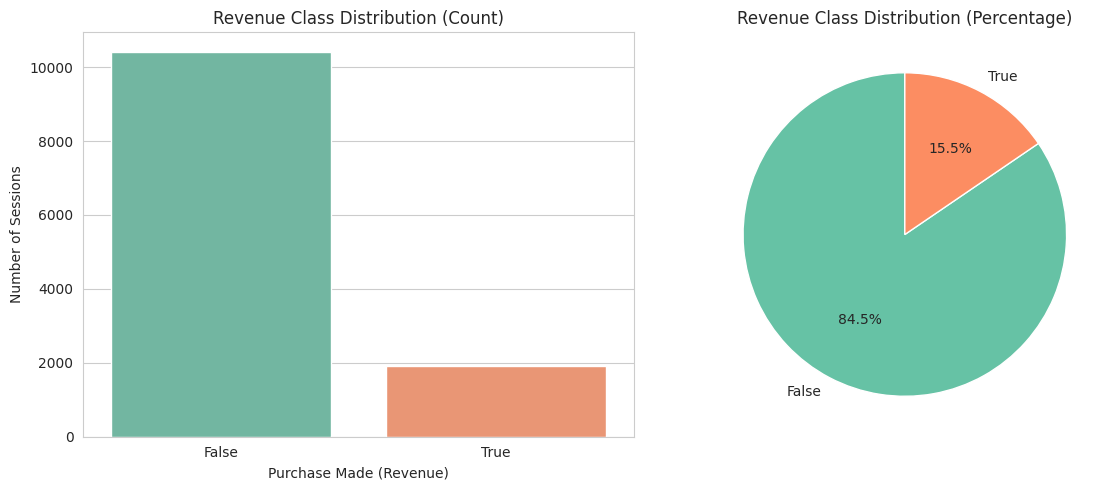

In [8]:
# Visualize the class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Revenue', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Revenue Class Distribution (Count)')
axes[0].set_xlabel('Purchase Made (Revenue)')
axes[0].set_ylabel('Number of Sessions')

axes[1].pie(revenue_counts, labels=revenue_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90)
axes[1].set_title('Revenue Class Distribution (Percentage)')

plt.tight_layout()
plt.show()


**Key Insight - Class Imbalance:**
Only about **15.5%** of sessions result in a purchase (`Revenue = True`), while
**84.5%** do not. This is a significantly **imbalanced classification problem**.

This has important implications:
- Accuracy alone will be a misleading metric (a model predicting "No Purchase" for
  every session would already get ~84.5% accuracy while being useless).
- We will need to rely on metrics like **Precision, Recall, F1-score, and ROC-AUC**.
- We will need to handle imbalance during model training (e.g., `class_weight='balanced'`
  or SMOTE oversampling) - this will be explored in the Model Training notebook.


## 5. Statistical Summary of Numerical Features

In [9]:
# Descriptive statistics for numerical columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


**Observation:**
- `Administrative_Duration`, `Informational_Duration`, `ProductRelated_Duration`,
  `BounceRates`, `ExitRates`, and `PageValues` all show a very large gap between the
  75th percentile and the max value. This strongly suggests **right-skewed
  distributions with outliers** - common for web-session duration/behavior data.
- `Informational` and `Informational_Duration` have a median of 0, meaning most
  users don't visit informational pages at all.
- `PageValues` also has a median of 0 - most sessions have zero page value, but a
  subset (likely the ones that convert) may have high page values.


## 6. Univariate Analysis - Numerical Features
We plot histograms to understand the shape/distribution of each numerical feature.

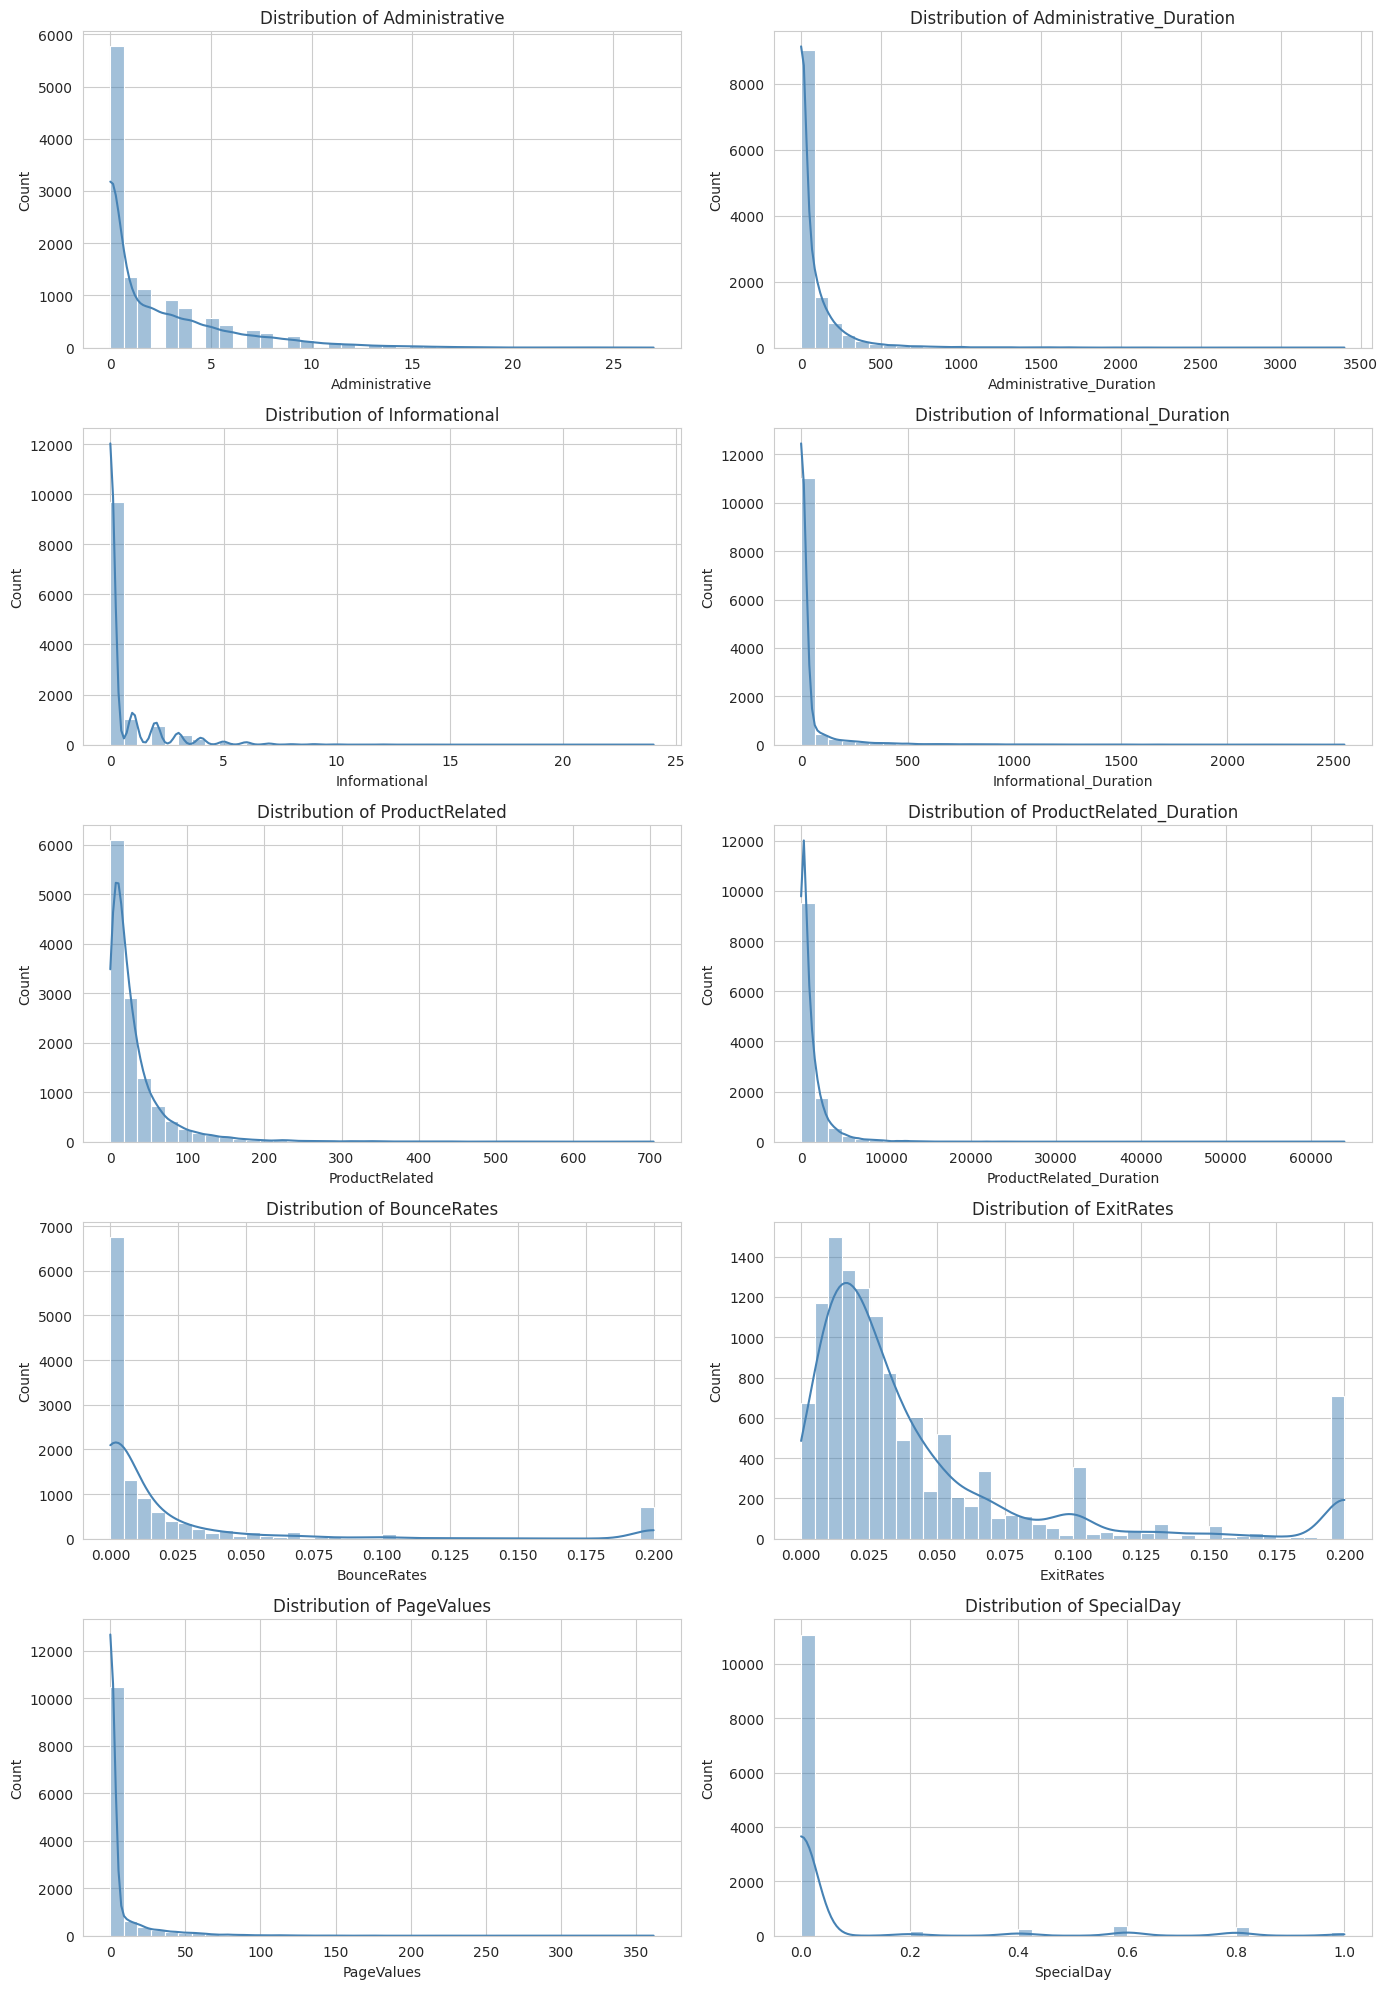

In [10]:
numerical_cols = ['Administrative', 'Administrative_Duration', 'Informational',
                   'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                   'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


**Observation:** Almost all numerical features are **heavily right-skewed**
(long tail towards higher values), with a large concentration of values at or near 0.
This is typical for web analytics data (most users browse very little, a few browse a
lot). We may consider log-transformation for some of these features during
preprocessing/feature engineering to reduce skewness.


## 7. Outlier Detection (Boxplots + IQR Method)

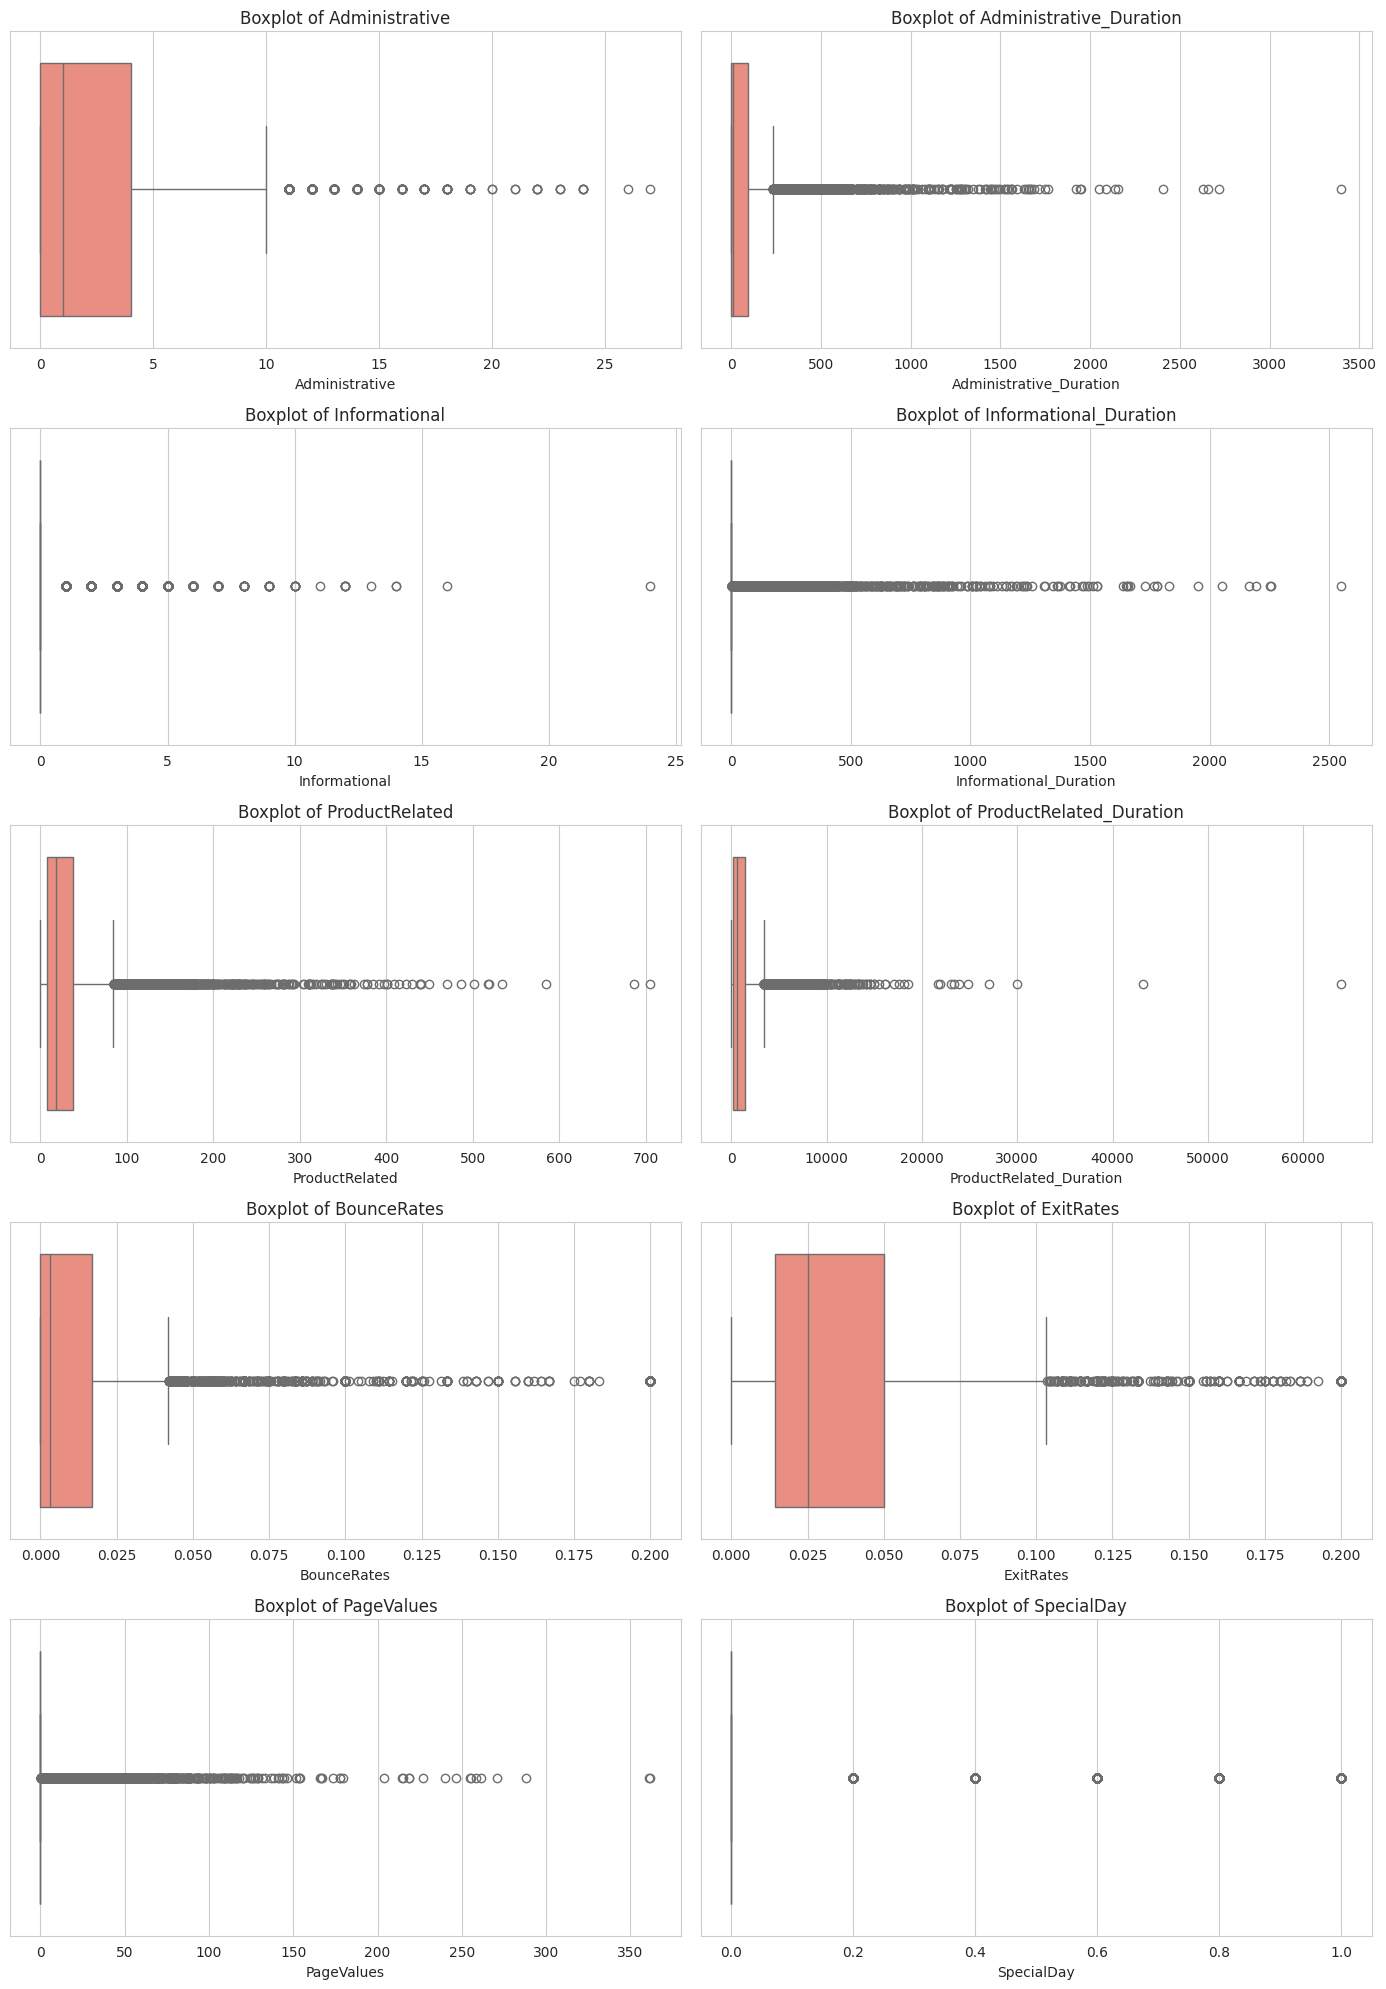

In [11]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


In [12]:
# Quantify outliers using the IQR (Interquartile Range) method
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers), len(outliers) / len(series) * 100

outlier_summary = []
for col in numerical_cols:
    count, pct = count_outliers_iqr(df[col])
    outlier_summary.append({'Feature': col, 'Outlier_Count': count, 'Outlier_Percent': round(pct, 2)})

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Percent', ascending=False)
outlier_df


,Feature,Outlier_Count,Outlier_Percent
8,PageValues,2730,22.14
2,Informational,2631,21.34
3,Informational_Duration,2405,19.51
6,BounceRates,1551,12.58
9,SpecialDay,1251,10.15
1,Administrative_Duration,1172,9.51
7,ExitRates,1099,8.91
4,ProductRelated,987,8.00
5,ProductRelated_Duration,961,7.79
0,Administrative,404,3.28


**Observation:** Several features (`PageValues`, `Informational`,
`Informational_Duration`, `BounceRates`, `Administrative_Duration`) show a high
percentage of statistical outliers using the strict IQR rule. However, many of these
"outliers" are likely genuine behavior (e.g., a highly engaged user who browses a lot
before buying, hence high `PageValues`), NOT data errors. We should be careful not to
blindly remove them, especially since `PageValues` is likely a strong predictor of
purchase. We will handle this thoughtfully in the Preprocessing notebook (e.g.,
capping/log-transform instead of deleting rows).


## 8. Bivariate Analysis - Numerical Features vs Target (`Revenue`)
Here we check how each numerical feature differs between sessions that resulted in a
purchase vs those that did not.

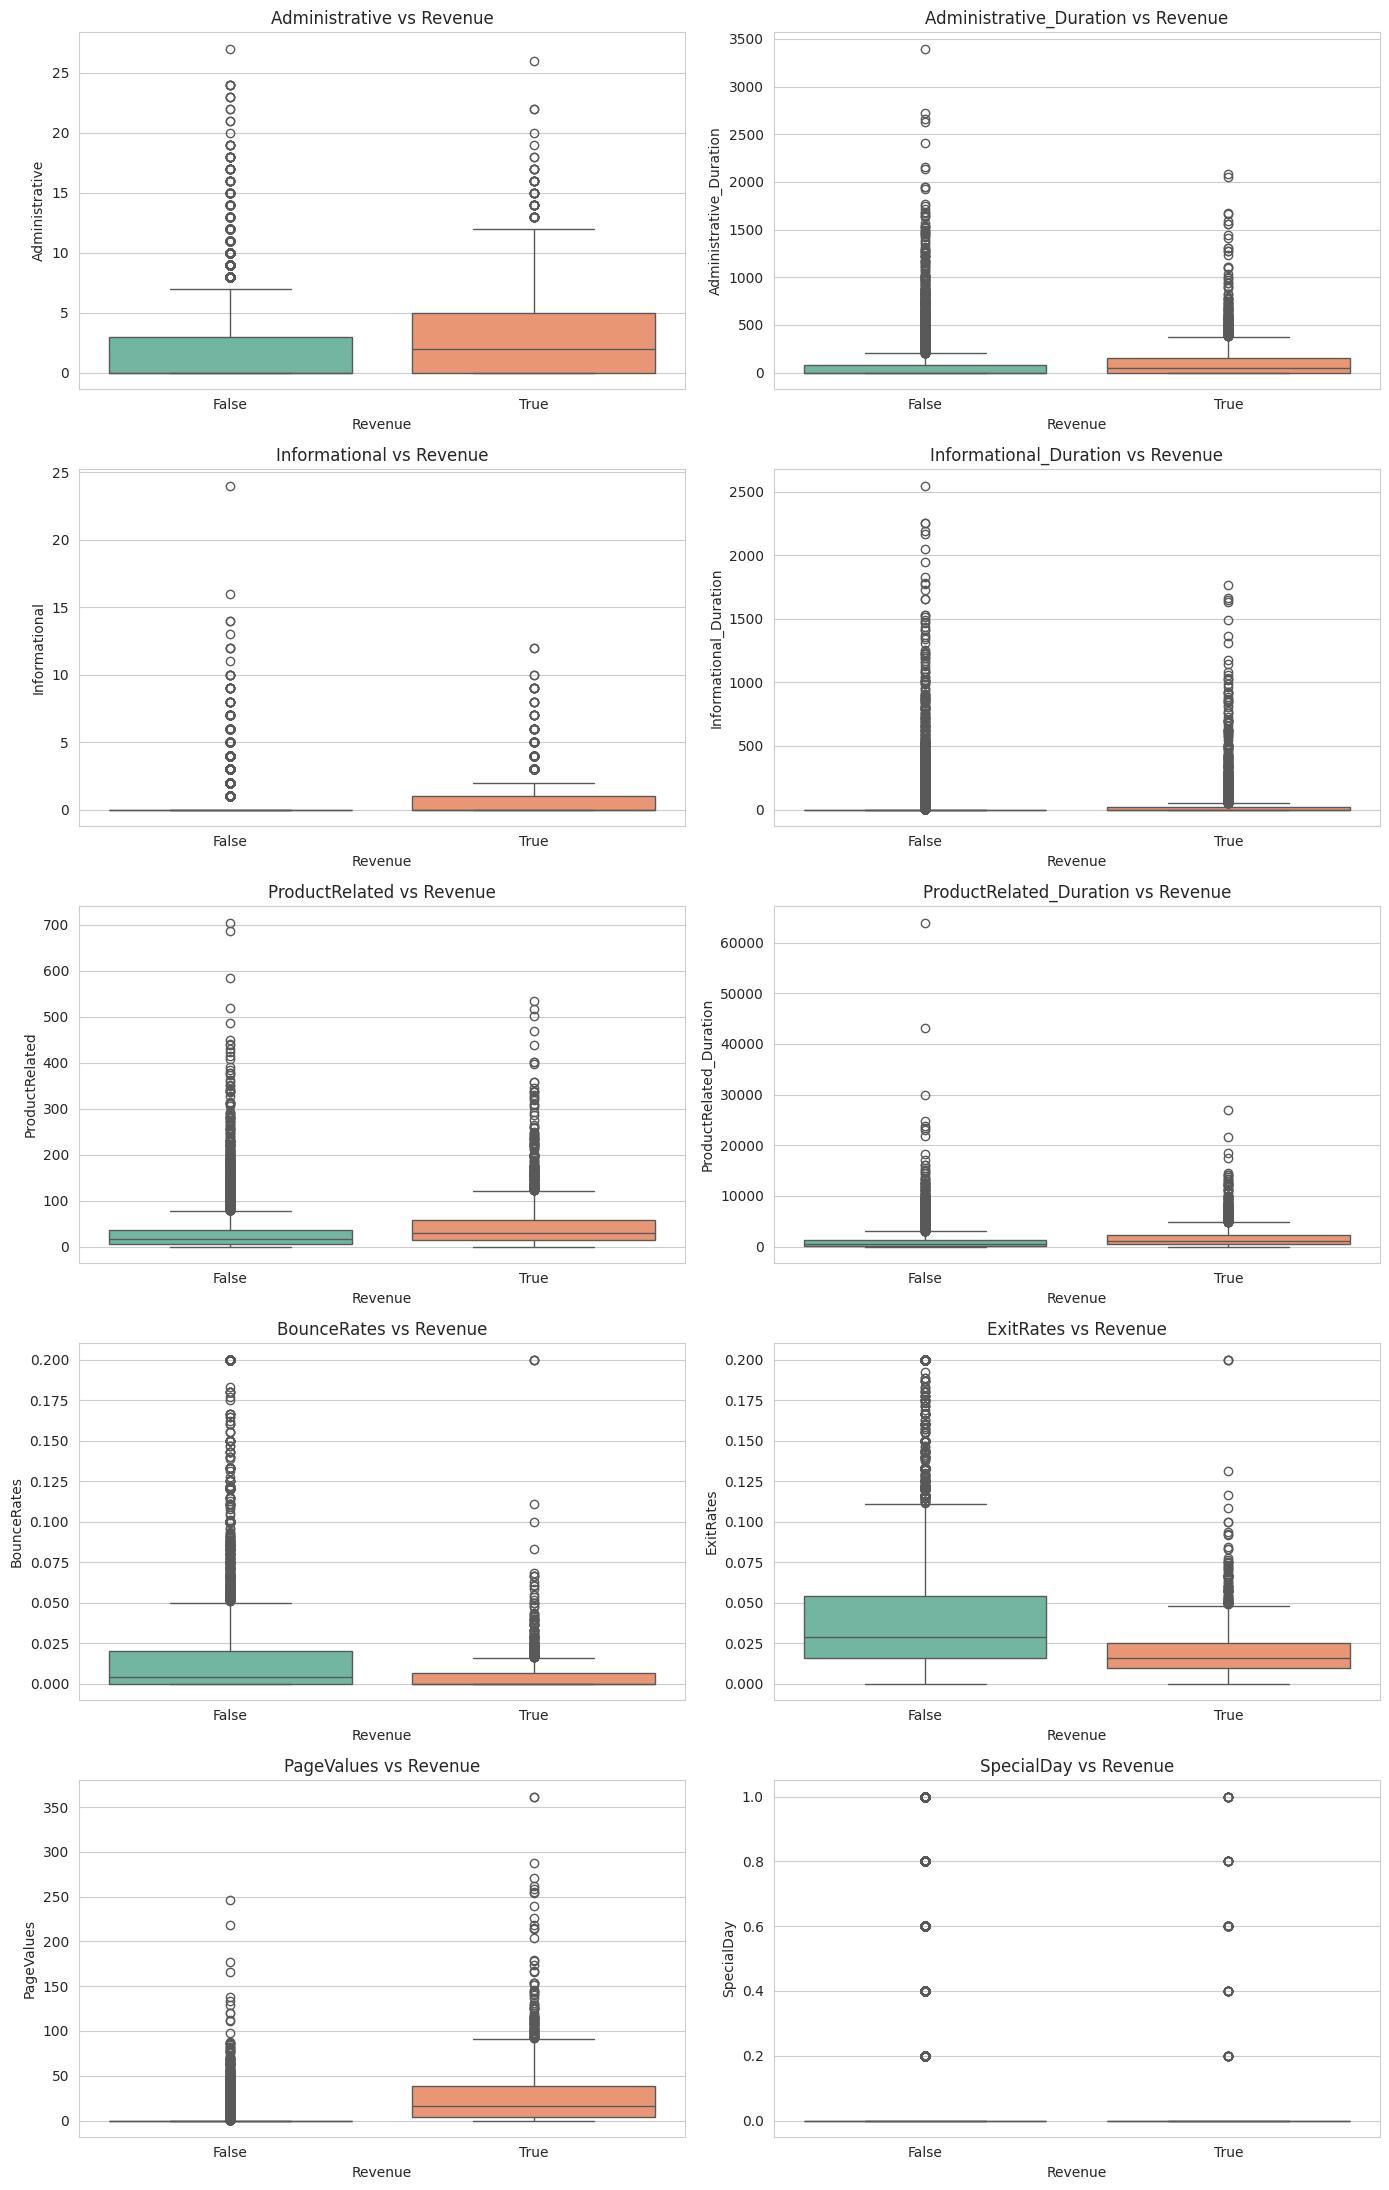

In [13]:
fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='Revenue', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Revenue')

plt.tight_layout()
plt.show()


**Key Insight:** `PageValues` shows a dramatically different distribution
between the two classes - sessions that end in a purchase (`Revenue=True`) have much
higher `PageValues` on average. This suggests `PageValues` will likely be one of the
**most important predictive features** in our model. `ProductRelated_Duration` and
`ProductRelated` also appear somewhat higher for purchasing sessions, while
`BounceRates` and `ExitRates` tend to be lower for purchasing sessions (makes
intuitive sense - users who bounce quickly don't buy).


In [14]:
# Compare mean values of each numerical feature grouped by Revenue
df.groupby('Revenue')[numerical_cols].mean().T


Revenue,False,True
Administrative,2.117732,3.393606
Administrative_Duration,73.740111,119.483244
Informational,0.451833,0.786164
Informational_Duration,30.236237,57.611427
ProductRelated,28.714642,48.210168
ProductRelated_Duration,1069.987809,1876.209615
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555
PageValues,1.975998,27.264518
SpecialDay,0.068432,0.023166


## 9. Correlation Heatmap (Numerical Features)

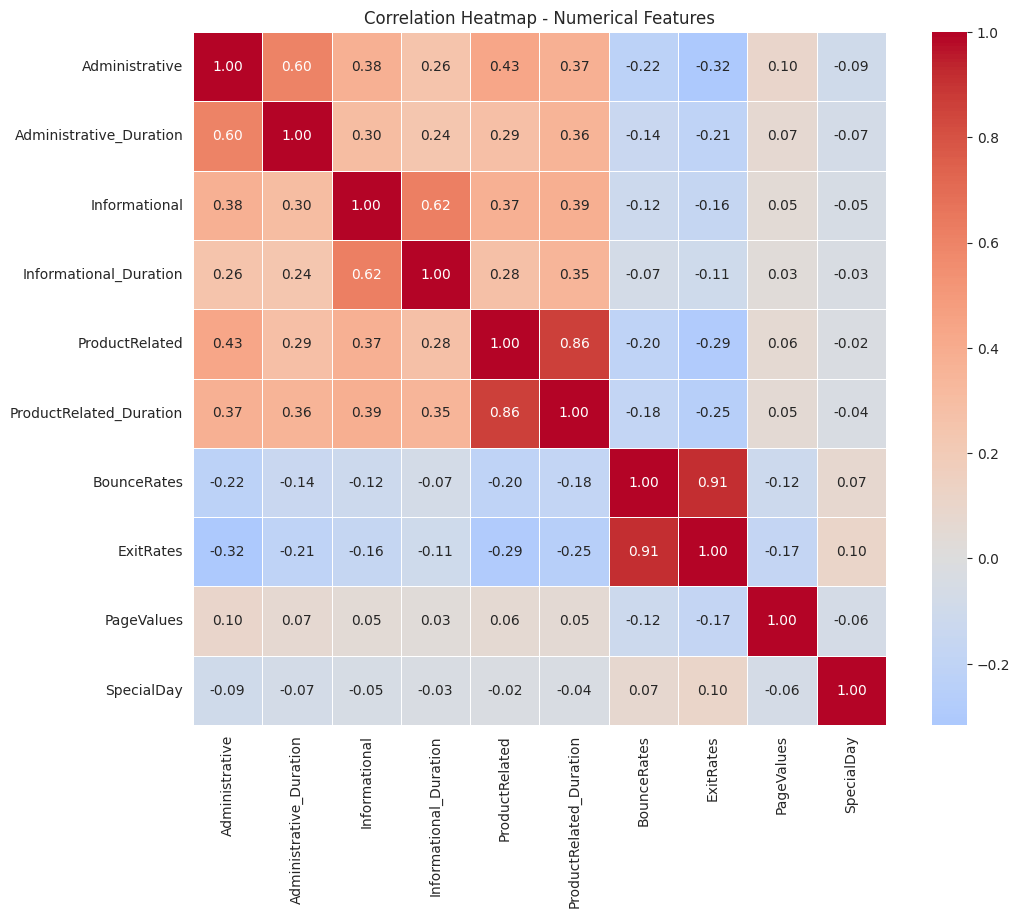

In [15]:
plt.figure(figsize=(12, 9))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Numerical Features')
plt.show()


**Observation - Multicollinearity:**
- `BounceRates` and `ExitRates` are highly correlated (as expected - both measure
  how quickly users leave the site).
- `Administrative` & `Administrative_Duration` are highly correlated, similarly
  `Informational` & `Informational_Duration`, and `ProductRelated` &
  `ProductRelated_Duration` (each "count" feature is naturally correlated with its
  matching "duration" feature).

This multicollinearity is important to keep in mind: tree-based models (Random
Forest, XGBoost, LightGBM) are fairly robust to multicollinearity, but we may still
consider feature engineering (e.g., combining or ratio features) to reduce redundancy.


## 10. Categorical Features Analysis

In [16]:
categorical_cols = ['Month', 'VisitorType', 'Weekend', 'OperatingSystems',
                     'Browser', 'Region', 'TrafficType']

for col in ['Month', 'VisitorType', 'Weekend']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


--- Month ---
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

--- VisitorType ---
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

--- Weekend ---
Weekend
False    9462
True     2868
Name: count, dtype: int64



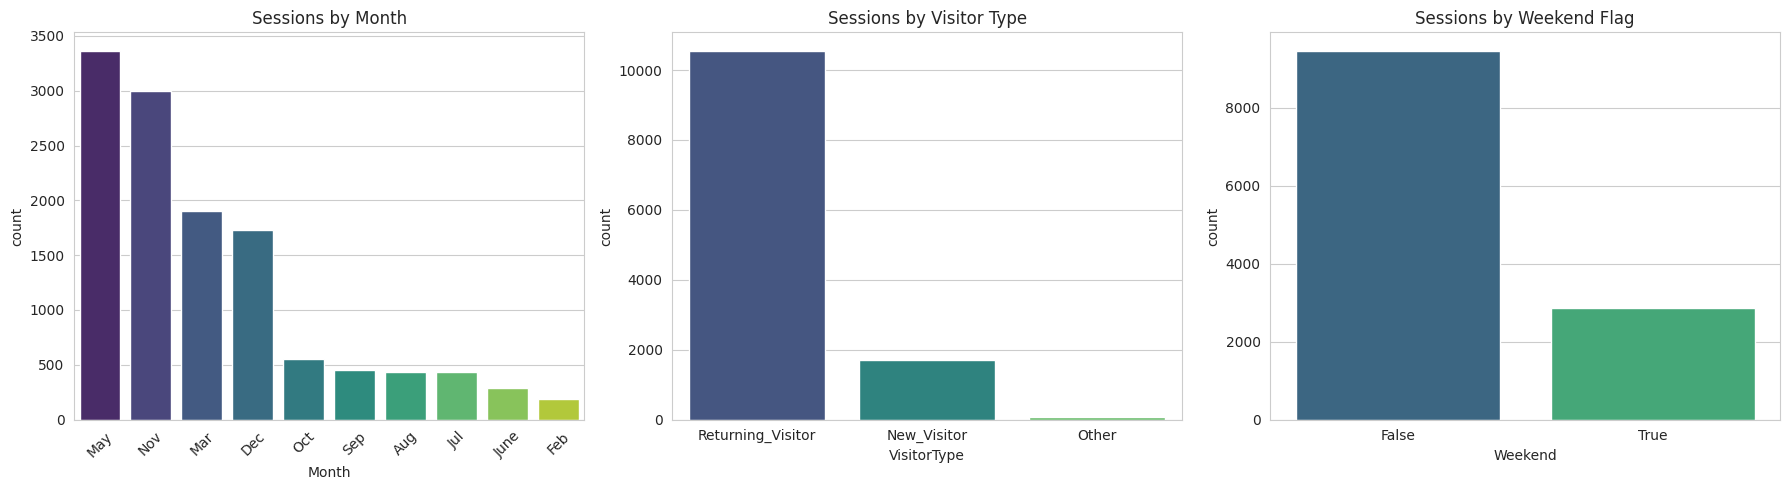

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='Month', data=df, order=df['Month'].value_counts().index, ax=axes[0], palette='viridis')
axes[0].set_title('Sessions by Month')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(x='VisitorType', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Sessions by Visitor Type')

sns.countplot(x='Weekend', data=df, ax=axes[2], palette='viridis')
axes[2].set_title('Sessions by Weekend Flag')

plt.tight_layout()
plt.show()


**Observation:** `May` has the highest number of sessions, and `Returning_Visitor`
dominates the visitor type. Notice there is NO data for `January` and `April` in the
`Month` column - important to remember since our model will never have seen these
months during training.


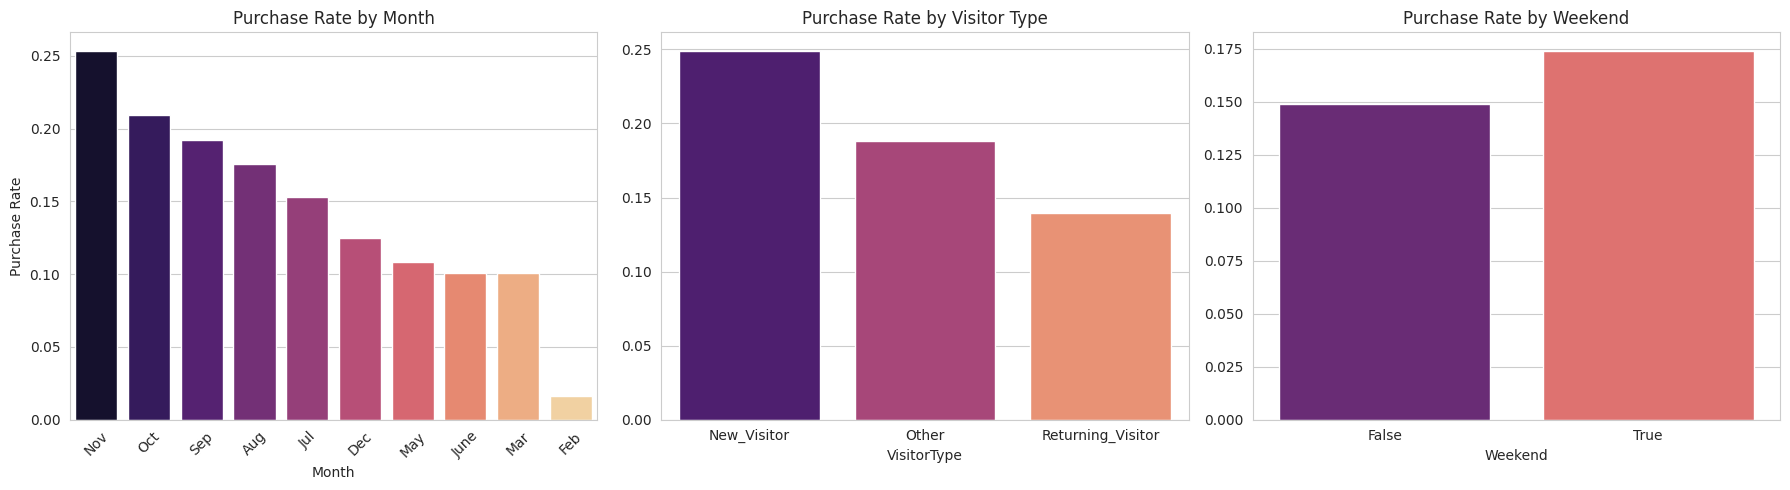

In [18]:
# Purchase (Revenue) rate by categorical feature
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

month_rate = df.groupby('Month')['Revenue'].mean().sort_values(ascending=False)
sns.barplot(x=month_rate.index, y=month_rate.values, ax=axes[0], palette='magma')
axes[0].set_title('Purchase Rate by Month')
axes[0].set_ylabel('Purchase Rate')
axes[0].tick_params(axis='x', rotation=45)

visitor_rate = df.groupby('VisitorType')['Revenue'].mean().sort_values(ascending=False)
sns.barplot(x=visitor_rate.index, y=visitor_rate.values, ax=axes[1], palette='magma')
axes[1].set_title('Purchase Rate by Visitor Type')

weekend_rate = df.groupby('Weekend')['Revenue'].mean()
sns.barplot(x=weekend_rate.index, y=weekend_rate.values, ax=axes[2], palette='magma')
axes[2].set_title('Purchase Rate by Weekend')

plt.tight_layout()
plt.show()


**Key Insight:** Purchase rate varies noticeably by `Month` (e.g., November has
a higher purchase rate - likely due to holiday shopping season). `New_Visitor` sessions
convert at a higher rate than `Returning_Visitor` sessions - interesting, since
returning visitors are more numerous but convert less often per-session. Weekend
sessions show a slightly different purchase rate compared to weekdays.


In [19]:
# OperatingSystems, Browser, Region, TrafficType are ID-like categorical columns.
# Let's check the number of unique categories in each (high-cardinality check).
for col in ['OperatingSystems', 'Browser', 'Region', 'TrafficType']:
    print(f"{col}: {df[col].nunique()} unique values")


OperatingSystems: 8 unique values
Browser: 13 unique values
Region: 9 unique values
TrafficType: 20 unique values


**Observation:** These 4 columns (`OperatingSystems`, `Browser`, `Region`,
`TrafficType`) are stored as integers but are actually **categorical IDs**, not
ordinal/continuous numbers (e.g., OperatingSystems `2` is not "twice as much" as
OperatingSystems `1`). We must treat them as categorical variables in preprocessing,
not as raw numbers.


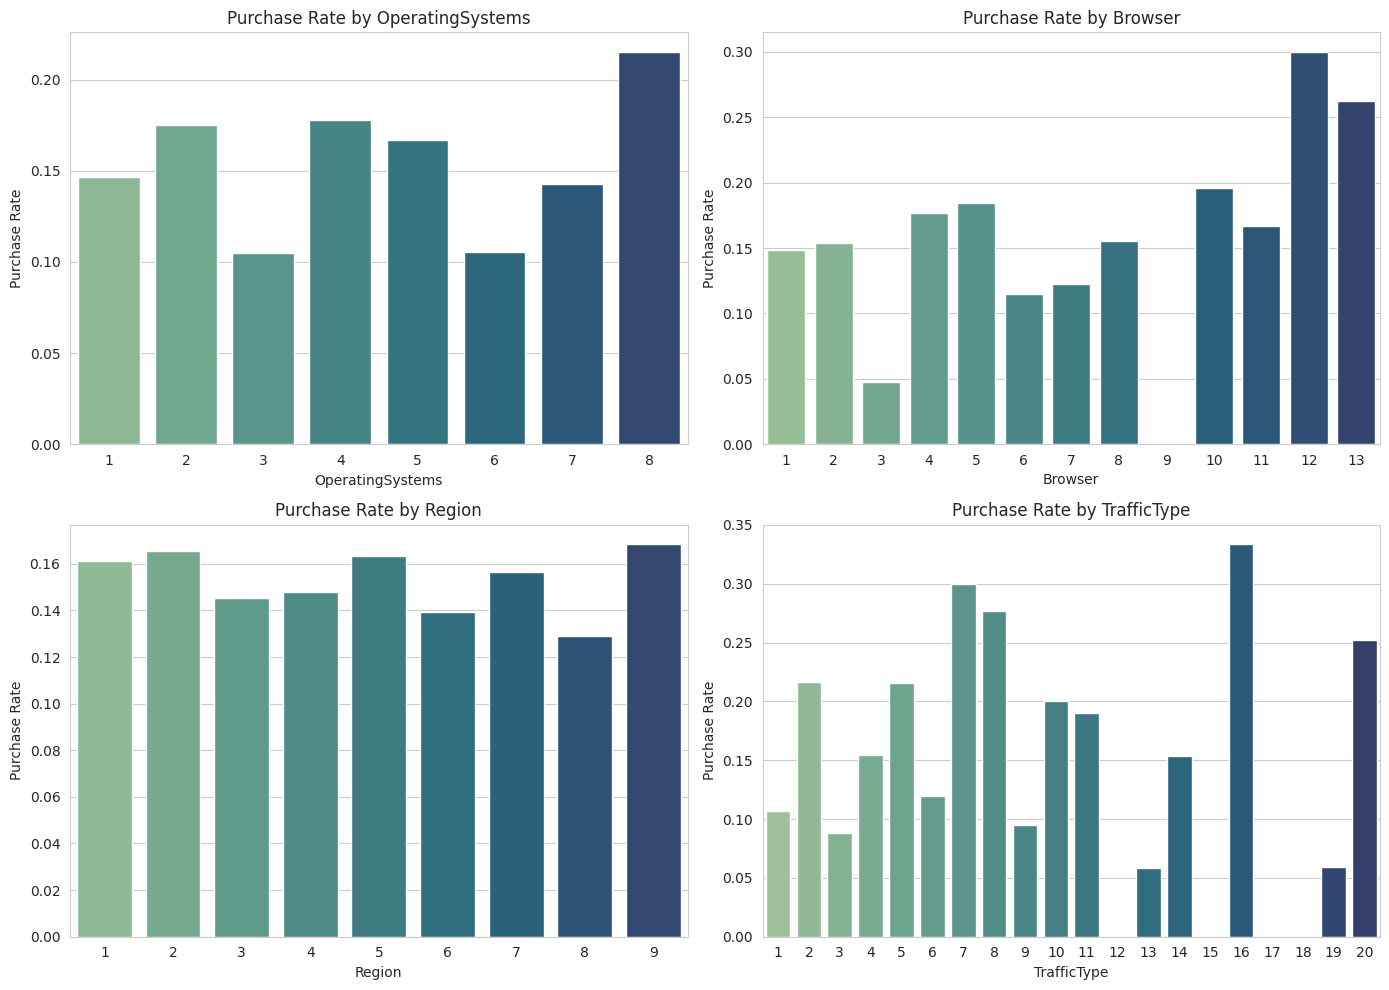

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(['OperatingSystems', 'Browser', 'Region', 'TrafficType']):
    rate = df.groupby(col)['Revenue'].mean()
    sns.barplot(x=rate.index, y=rate.values, ax=axes[i], palette='crest')
    axes[i].set_title(f'Purchase Rate by {col}')
    axes[i].set_ylabel('Purchase Rate')

plt.tight_layout()
plt.show()


## 11. Pairwise Relationships of Key Features
Let's visualize the relationship between the most promising features
(`PageValues`, `ExitRates`, `ProductRelated_Duration`) colored by the target.

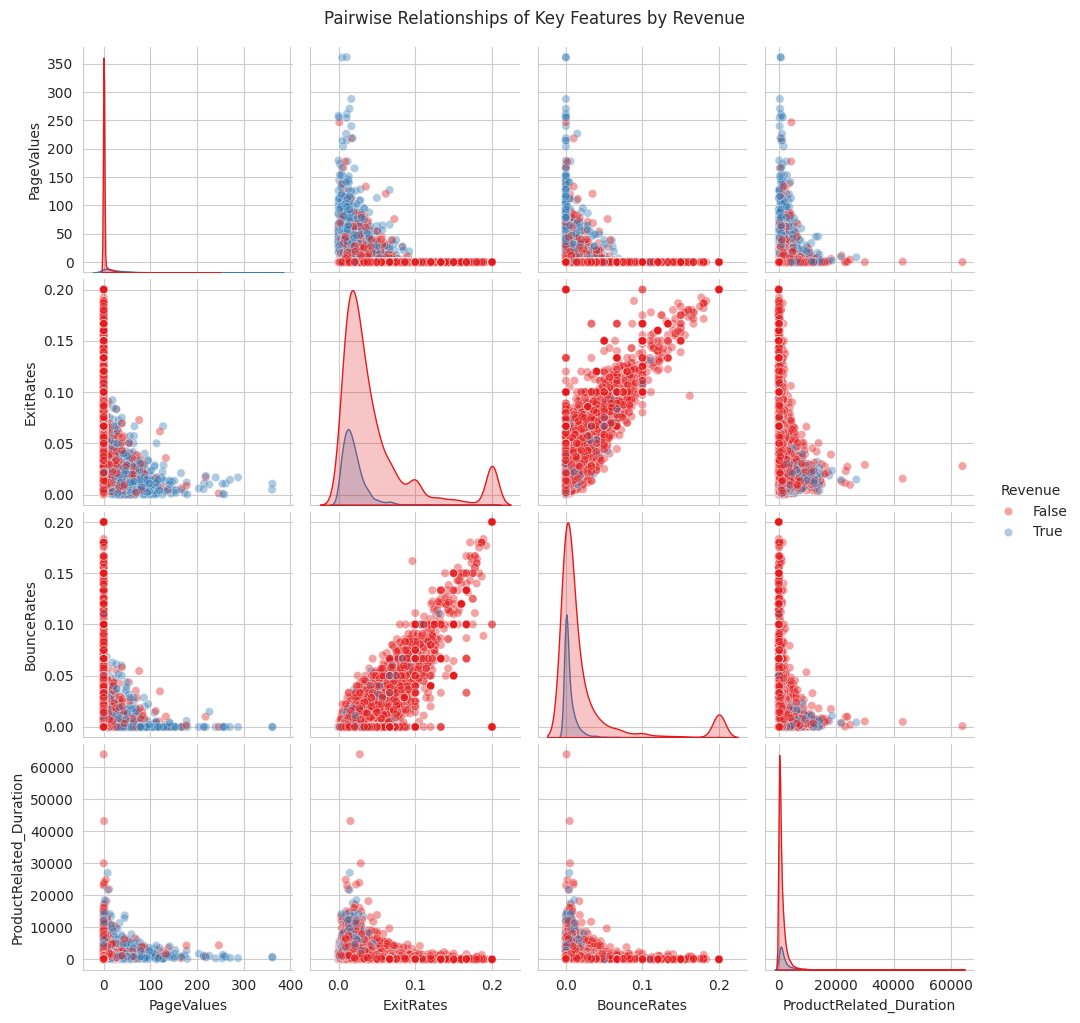

In [21]:
key_features = ['PageValues', 'ExitRates', 'BounceRates', 'ProductRelated_Duration', 'Revenue']
sns.pairplot(df[key_features], hue='Revenue', palette='Set1', diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairwise Relationships of Key Features by Revenue', y=1.02)
plt.show()


## 12. Summary of Key EDA Insights

1. **No missing values** in the dataset - good, but we did find some duplicate rows
   that we will investigate/handle in preprocessing.
2. **Significant class imbalance**: only ~15.5% of sessions convert to a purchase.
   This must be addressed during model training (SMOTE / class_weight).
3. **Numerical features are right-skewed** with many outliers - we should consider
   transformations (log transform) rather than blindly removing outliers, since many
   "outliers" (e.g., high PageValues) are likely genuine and highly predictive.
4. **`PageValues` looks like the strongest single predictor** - purchasing sessions
   have far higher PageValues than non-purchasing sessions.
5. **`BounceRates` and `ExitRates` are negatively associated with purchase** - lower
   values (more engaged sessions) tend to convert more.
6. **Multicollinearity exists** between count/duration pairs (e.g.,
   `Administrative` & `Administrative_Duration`) and between `BounceRates` &
   `ExitRates`. Tree models handle this reasonably well, but it's good to keep in
   mind for feature engineering / feature selection.
7. **`Month`, `VisitorType`, and `Weekend` all affect purchase rate** and should be
   properly encoded as categorical variables.
8. **`OperatingSystems`, `Browser`, `Region`, `TrafficType`** are ID-like categorical
   columns stored as integers - must NOT be treated as continuous numeric features.
9. **`Month` is missing January and April** entirely - a data coverage gap to be
   aware of.

### Next Steps
Proceed to `02_Preprocessing.ipynb` where we will:
- Handle duplicate rows.
- Correctly encode categorical variables.
- Handle skewness/outliers appropriately.
- Split data into train/test sets (before any transformation that could leak
  information, to avoid data leakage).
